# Food Delivery Demand Pulse — Case 3
## When Does Demand Really Spike, and Are We Paying Surge Correctly?

**Dataset:** `case3_food_delivery_orders.csv` — 50,000 orders | 7 cities | 9 cuisines | 90 days (Jan–Mar 2025)  
**Goal:** Identify true demand peaks → build a 7-day forecast → deliver 3 concrete policy recommendations.

---

In [48]:
import warnings
warnings.filterwarnings("ignore")
!pip install statsmodels
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_PATH = Path("case3_food_delivery_orders.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/case3_food_delivery_orders.csv")

assert DATA_PATH.exists(), f"Could not find {DATA_PATH}"
print(f"Using file: {DATA_PATH}")


Using file: case3_food_delivery_orders.csv



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["date"] = df["timestamp"].dt.date
df["day_of_week"] = df["timestamp"].dt.day_name()
df["hour"] = df["timestamp"].dt.hour
df["is_weekend"] = df["timestamp"].dt.dayofweek >= 5
df["week"] = df["timestamp"].dt.isocalendar().week.astype(int)


# ── Data validation ──────────────────────────────────────
print(f"\nShape: {df.shape}")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate order IDs: {df['order_id'].duplicated().sum()}")
print(f"Surge applied overall: {df['surge_applied'].mean()*100:.1f}% of orders")


df.head()



Shape: (50000, 13)
Date range: 2025-01-01 to 2025-03-31
Missing values: 0
Duplicate order IDs: 0
Surge applied overall: 23.9% of orders


,order_id,timestamp,city,restaurant_id,cuisine,order_value,delivery_time_min,surge_applied,date,day_of_week,hour,is_weekend,week
0,ORD138520,2025-01-01 00:00:00,Delhi,R0521,Fast Food,185,31,0,2025-01-01,Wednesday,0,False,1
1,ORD132134,2025-01-01 00:06:00,Mumbai,R0021,Italian,792,46,0,2025-01-01,Wednesday,0,False,1
2,ORD111938,2025-01-01 00:36:00,Chennai,R0221,Continental,702,34,0,2025-01-01,Wednesday,0,False,1
3,ORD134651,2025-01-01 00:51:00,Pune,R0498,Italian,468,35,0,2025-01-01,Wednesday,0,False,1
4,ORD143104,2025-01-01 01:17:00,Delhi,R0448,Continental,887,50,0,2025-01-01,Wednesday,1,False,1


---
## 1. Hourly Demand — Two Clear Peaks

We start with the most important question: *when are people ordering?*

The bars below show total orders by hour. The orange line overlays the surge application rate.  
**True demand peaks: Lunch (12–13) and Dinner (19–21).** Everything else is structurally low.

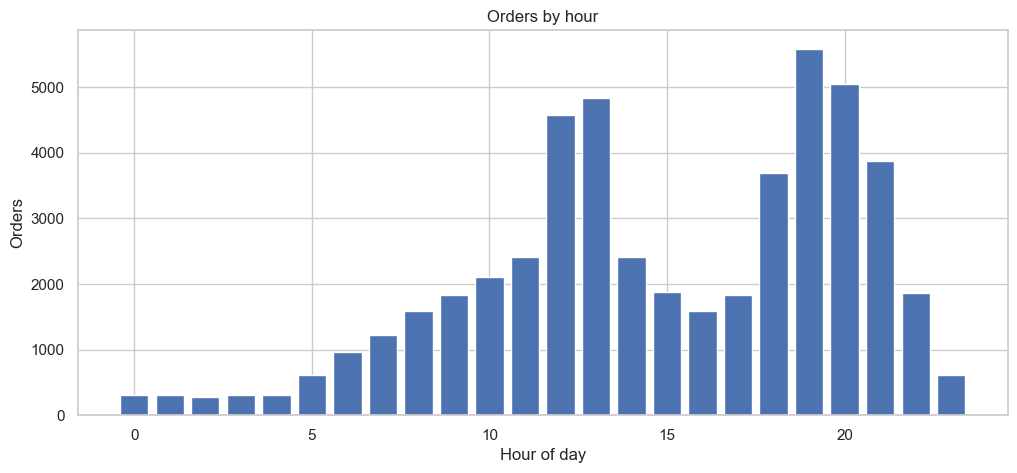

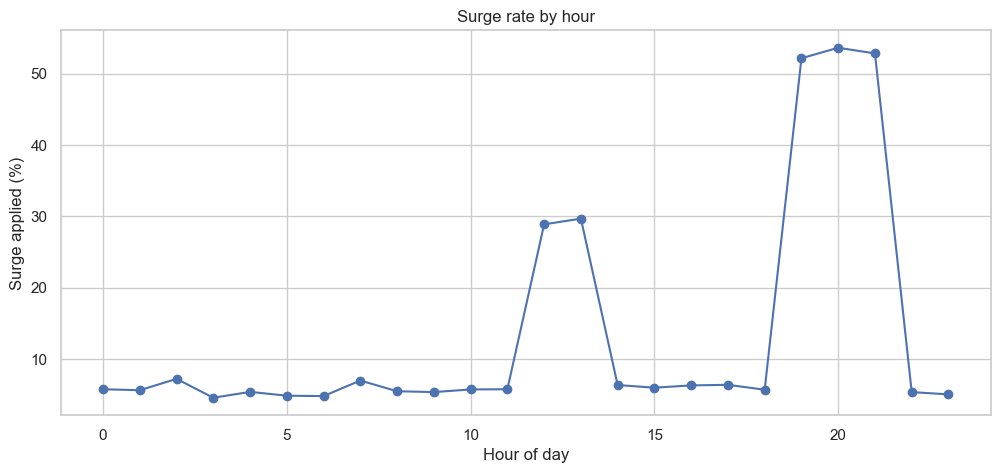

,hour,orders,surge_rate,avg_delivery_time,avg_order_value
19,19,5586,0.521482,43.820265,328.844970
20,20,5052,0.536223,43.951900,329.946160
13,13,4826,0.296726,43.722752,331.972648
12,12,4571,0.288777,43.779042,328.998469
21,21,3877,0.528243,43.698220,332.551715
18,18,3683,0.057019,37.716535,324.284822
11,11,2410,0.057676,37.081743,333.511618
14,14,2407,0.063565,37.136685,331.426672


In [50]:
hourly = (
    df.groupby("hour")
      .agg(orders=("order_id", "size"),
           surge_rate=("surge_applied", "mean"),
           avg_delivery_time=("delivery_time_min", "mean"),
           avg_order_value=("order_value", "mean"))
      .reset_index()
)

fig, ax = plt.subplots()
ax.bar(hourly["hour"], hourly["orders"])
ax.set_title("Orders by hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Orders")
plt.show()

fig, ax = plt.subplots()
ax.plot(hourly["hour"], hourly["surge_rate"] * 100, marker="o")
ax.set_title("Surge rate by hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Surge applied (%)")
plt.show()

display(hourly.sort_values("orders", ascending=False).head(8))

**Key finding:** Surge rate at dinner (52%) and lunch (29%) tracks actual demand — those incentives are earning their keep (delivery time is ~3.5–4 min slower at peaks, confirming rider pressure).  
However, surge is also applied at hours 0–9 and 22–23 at ~5–6%, where there is zero delivery-time stress. That is pure waste.

### 1a. Surge Waste Quantification — Putting a Rupee Figure on the Problem

In [51]:
# ── Surge waste by hour block ────────────────────────────
surge_by_hour = df.groupby("hour").agg(
    total_orders=("order_id", "count"),
    surge_orders=("surge_applied", "sum")
).reset_index()
surge_by_hour["surge_pct"] = (surge_by_hour["surge_orders"] / surge_by_hour["total_orders"] * 100).round(1)

hour_groups = {
    "Dinner  (19-21)  HIGH demand  [Justified]":       [19, 20, 21],
    "Lunch   (12-13)  MID demand   [Justified]":       [12, 13],
    "Transition (10-11, 14-18) MODEST [Partially]":   [10, 11, 14, 15, 16, 17, 18],
    "Night   (0-9, 22-23) LOW demand  [WASTED]":       list(range(0, 10)) + [22, 23],
}

print(f"{'Segment':<50} {'Orders':>8} {'Surge':>8} {'Surge%':>8}")
print("-" * 78)
for label, hours in hour_groups.items():
    sub = surge_by_hour[surge_by_hour["hour"].isin(hours)]
    tot, sur = sub["total_orders"].sum(), sub["surge_orders"].sum()
    print(f"{label:<50} {tot:>8,} {sur:>8,} {sur/tot*100:>7.1f}%")

# ── Financial impact ─────────────────────────────────────
SURGE_INCENTIVE_PER_ORDER = 25   # Rs. conservative rider bonus

off_peak_hours = list(range(0, 10)) + [22, 23]
wasted_surge_90d = surge_by_hour[surge_by_hour["hour"].isin(off_peak_hours)]["surge_orders"].sum()
wasted_monthly = wasted_surge_90d * SURGE_INCENTIVE_PER_ORDER * (30 / 90)

transition_hours = [10, 11, 14, 15, 16, 17, 18]
transition_surge_90d = surge_by_hour[surge_by_hour["hour"].isin(transition_hours)]["surge_orders"].sum()
partial_save_monthly = transition_surge_90d * SURGE_INCENTIVE_PER_ORDER * 0.5 * (30 / 90)

print(f"\nOff-peak wasted surge (90 days):      {wasted_surge_90d:,} orders")
print(f"  Estimated monthly cost:              Rs.{wasted_monthly:,.0f}")
print(f"Transition hours partial saving:       Rs.{partial_save_monthly:,.0f}/month")
print(f"Total potential monthly saving:        Rs.{wasted_monthly + partial_save_monthly:,.0f}")


Segment                                              Orders    Surge   Surge%
------------------------------------------------------------------------------
Dinner  (19-21)  HIGH demand  [Justified]            14,515    7,670    52.8%
Lunch   (12-13)  MID demand   [Justified]             9,397    2,752    29.3%
Transition (10-11, 14-18) MODEST [Partially]         15,898      952     6.0%
Night   (0-9, 22-23) LOW demand  [WASTED]            10,190      563     5.5%

Off-peak wasted surge (90 days):      563 orders
  Estimated monthly cost:              Rs.4,692
Transition hours partial saving:       Rs.3,967/month
Total potential monthly saving:        Rs.8,658


---
## 2. Day of Week — Weekend Surge is 57% Higher Than Weekdays

Orders are almost flat across the week (CV ~3%), but surge application is dramatically different:  
weekdays average **20.5%** surge vs weekends at **32.2%**. This means the current policy is spending  
significantly more on rider incentives on Saturdays and Sundays — but that spike is predictable and  
can be pre-scheduled instead of triggered reactively.

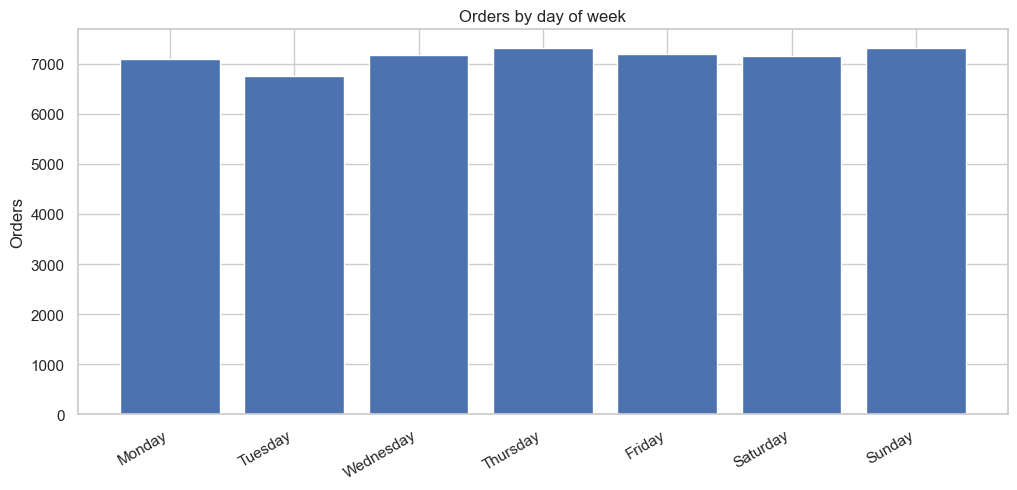

,day_of_week,orders
0,Monday,7096
1,Tuesday,6748
2,Wednesday,7183
3,Thursday,7318
4,Friday,7189
5,Saturday,7151
6,Sunday,7315


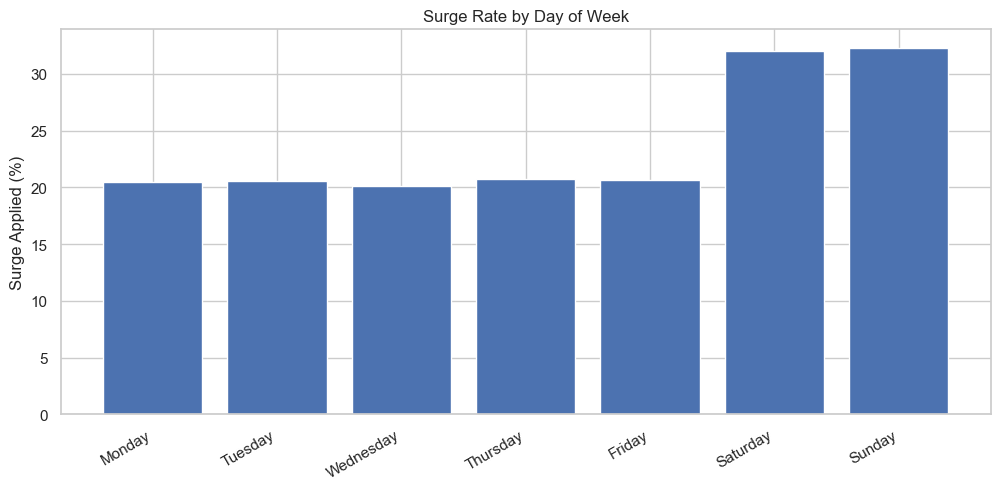

,day_of_week,total_orders,surge_orders,surge_rate
0,Monday,7096,1451,0.204481
1,Tuesday,6748,1388,0.205691
2,Wednesday,7183,1443,0.200891
3,Thursday,7318,1518,0.207434
4,Friday,7189,1486,0.206705
5,Saturday,7151,2289,0.320095
6,Sunday,7315,2362,0.322898


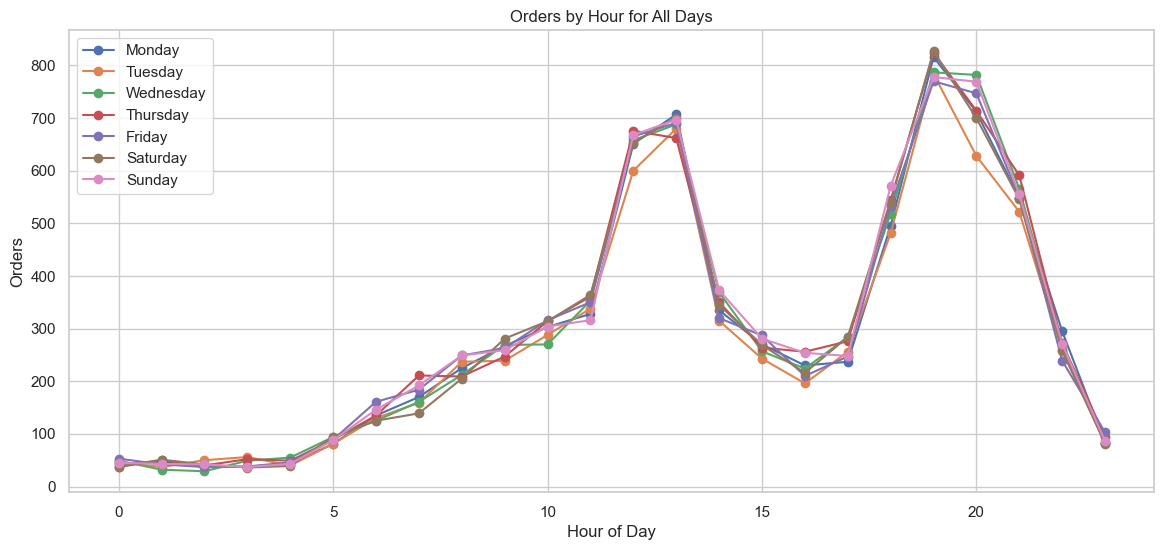

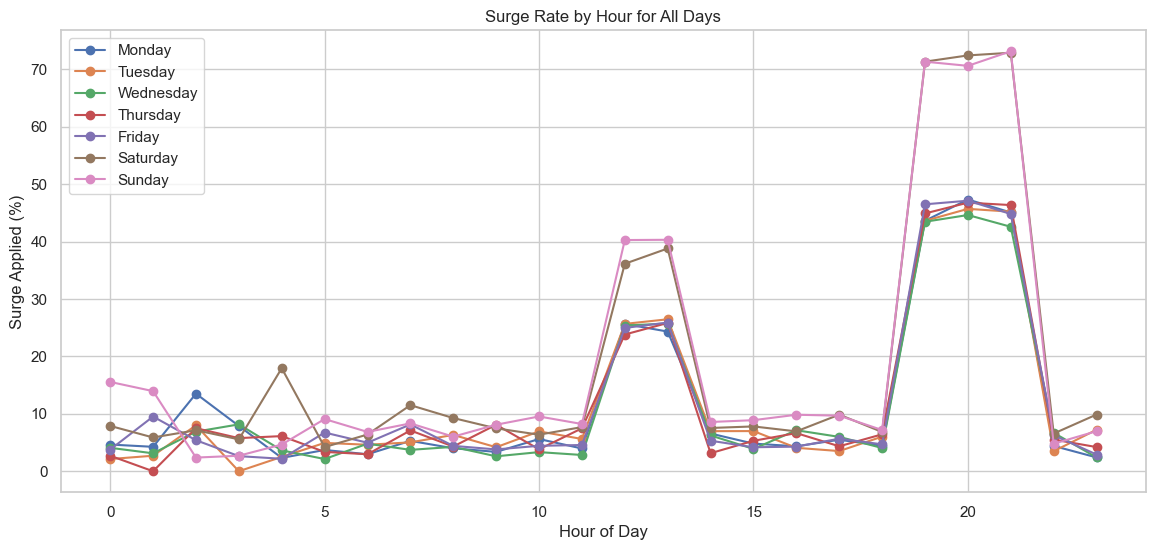

,day_of_week,hour,orders,surge_rate
0,Friday,0,53,0.037736
1,Friday,1,42,0.095238
2,Friday,2,37,0.054054
3,Friday,3,38,0.026316
4,Friday,4,46,0.021739
...,...,...,...,...
163,Wednesday,19,787,0.434562
164,Wednesday,20,782,0.446292
165,Wednesday,21,566,0.425795
166,Wednesday,22,269,0.066914


In [52]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow = (
    df.groupby("day_of_week")
      .size()
      .reindex(dow_order)
      .reset_index(name="orders")
)

fig, ax = plt.subplots()
ax.bar(dow["day_of_week"], dow["orders"])
ax.set_title("Orders by day of week")
ax.set_xlabel("")
ax.set_ylabel("Orders")
plt.xticks(rotation=30, ha="right")
plt.show()

display(dow)

dow_surge = (
    df.groupby("day_of_week")
      .agg(
          total_orders=("order_id", "size"),
          surge_orders=("surge_applied", "sum"),
          surge_rate=("surge_applied", "mean")
      )
      .reindex(dow_order)
      .reset_index()
)

# plot surge rate
fig, ax = plt.subplots()

ax.bar(
    dow_surge["day_of_week"],
    dow_surge["surge_rate"] * 100
)

ax.set_title("Surge Rate by Day of Week")
ax.set_xlabel("")
ax.set_ylabel("Surge Applied (%)")

plt.xticks(rotation=30, ha="right")

plt.show()

# display table
display(dow_surge)

# aggregate data by day and hour
day_hourly = (
    df.groupby(["day_of_week", "hour"])
      .agg(
          orders=("order_id", "size"),
          surge_rate=("surge_applied", "mean")
      )
      .reset_index()
)

# proper weekday order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# =========================
# ORDERS BY HOUR FOR ALL DAYS
# =========================

fig, ax = plt.subplots(figsize=(14,6))

for day in day_order:

    temp = day_hourly[
        day_hourly["day_of_week"] == day
    ]

    ax.plot(
        temp["hour"],
        temp["orders"],
        marker="o",
        label=day
    )

ax.set_title("Orders by Hour for All Days")

ax.set_xlabel("Hour of Day")

ax.set_ylabel("Orders")

ax.legend()

plt.show()


# =========================
# SURGE RATE BY HOUR FOR ALL DAYS
# =========================

fig, ax = plt.subplots(figsize=(14,6))

for day in day_order:

    temp = day_hourly[
        day_hourly["day_of_week"] == day
    ]

    ax.plot(
        temp["hour"],
        temp["surge_rate"] * 100,
        marker="o",
        label=day
    )

ax.set_title("Surge Rate by Hour for All Days")

ax.set_xlabel("Hour of Day")

ax.set_ylabel("Surge Applied (%)")

ax.legend()

plt.show()


# =========================
# DISPLAY TABLE
# =========================

display(day_hourly)

### 2a. Hour × Day Heatmap — Weekend Evenings Are the Hottest Combination

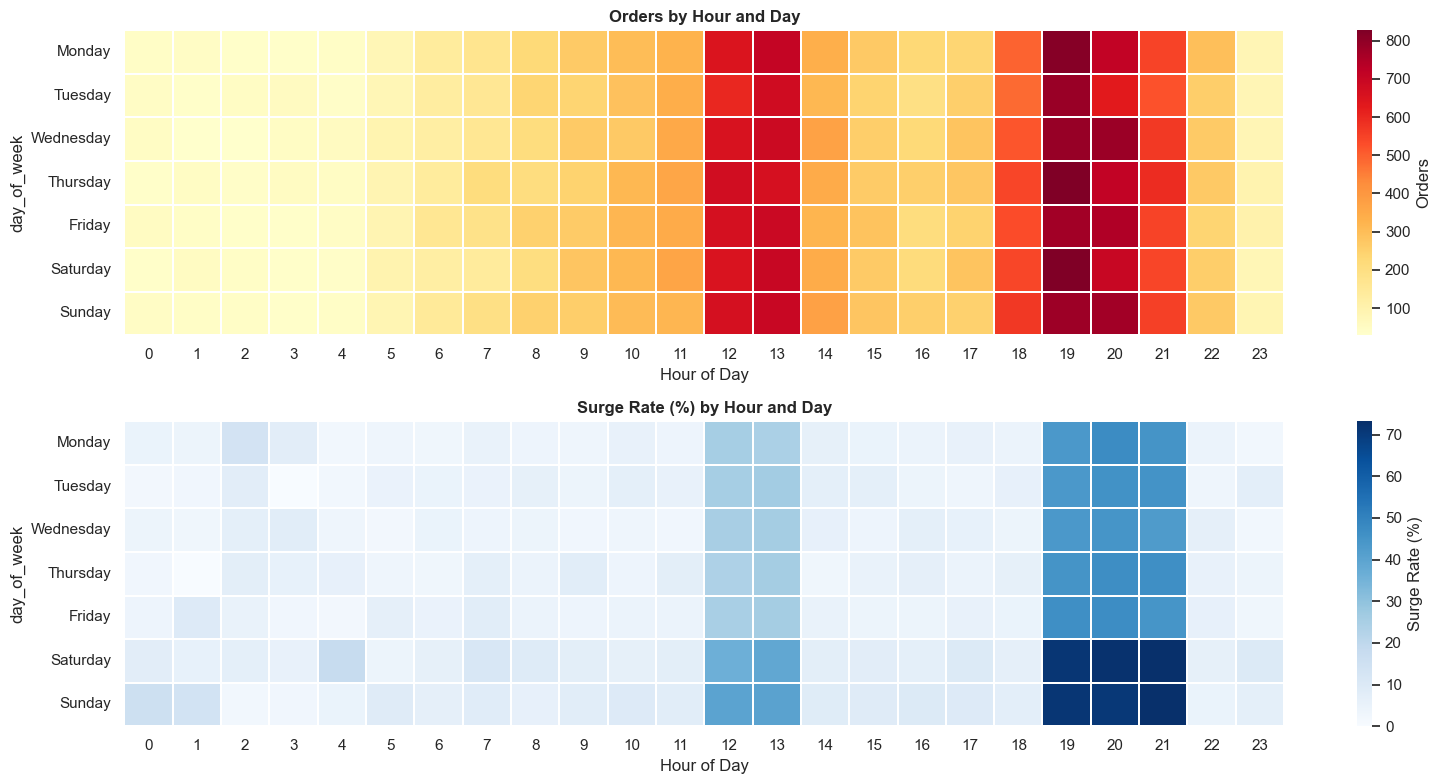

In [53]:
import seaborn as sns

day_hourly = (
    df.groupby(["day_of_week", "hour"])
      .agg(
          orders=("order_id", "size"),
          surge_rate=("surge_applied", "mean")
      )
      .reset_index()
)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Pivot for heatmap
pivot_orders = day_hourly.pivot(index="day_of_week", columns="hour", values="orders").reindex(day_order)
pivot_surge  = day_hourly.pivot(index="day_of_week", columns="hour", values="surge_rate").reindex(day_order) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))

sns.heatmap(pivot_orders, cmap="YlOrRd", ax=ax1, linewidths=0.3,
            cbar_kws={"label": "Orders"})
ax1.set_title("Orders by Hour and Day", fontweight="bold")
ax1.set_xlabel("Hour of Day")

sns.heatmap(pivot_surge, cmap="Blues", ax=ax2, linewidths=0.3,
            cbar_kws={"label": "Surge Rate (%)"})
ax2.set_title("Surge Rate (%) by Hour and Day", fontweight="bold")
ax2.set_xlabel("Hour of Day")

plt.tight_layout()
plt.show()


**Key finding:** Weekend evening slots (Sat–Sun, 19–21) are the single hottest demand+surge combination.  
This pattern is 100% predictable — meaning we can pre-schedule weekend surge rather than trigger it reactively.

---
## 3. City Analysis — All Cities Follow the Same Hourly Pattern

Every city shows identical lunch and dinner peaks. Surge rates across cities are nearly identical (23–24%).  
The key difference is **volume**: Bangalore and Mumbai together account for 42% of all orders.

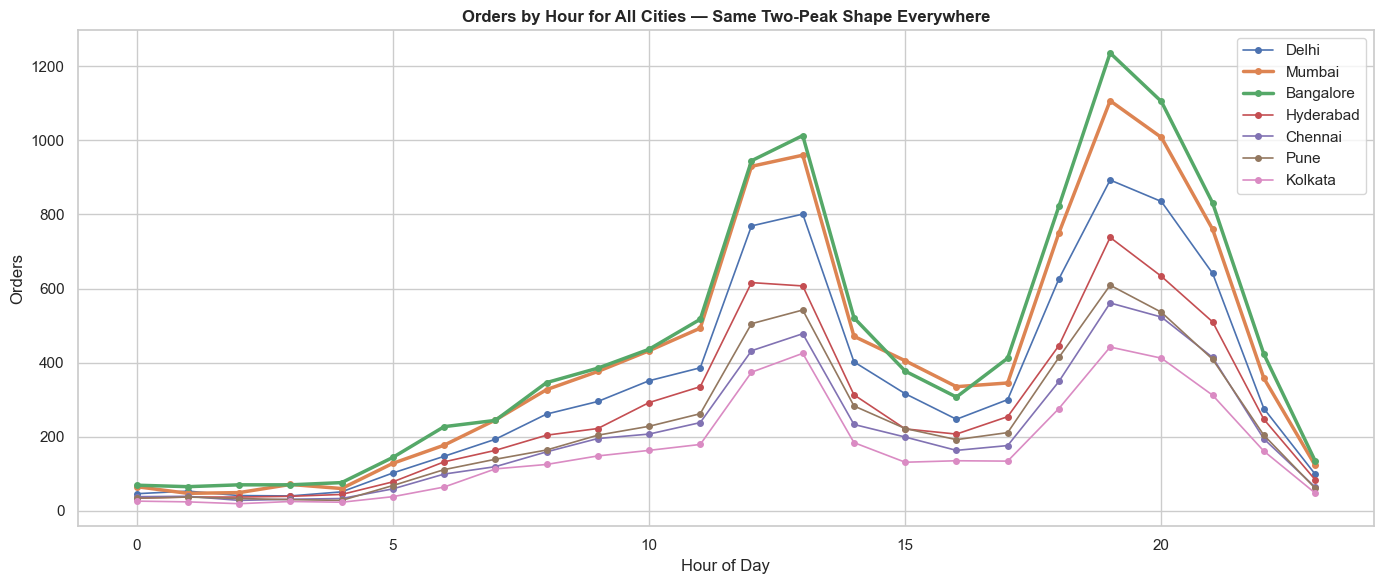

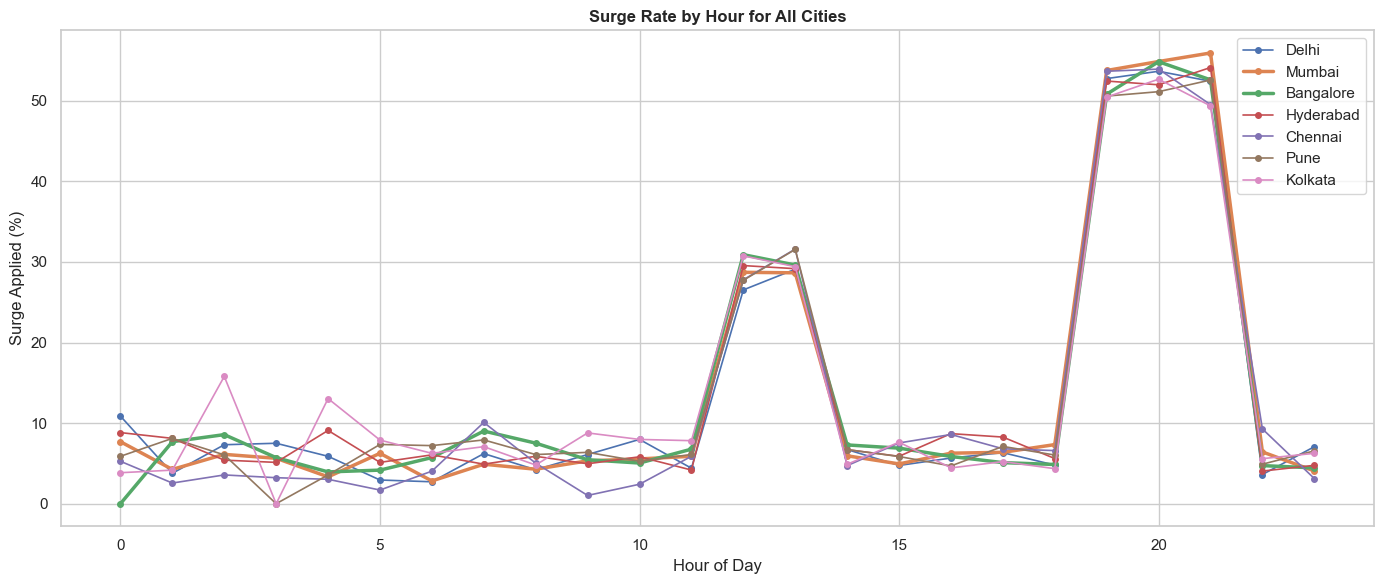

,orders,avg_order_value,avg_delivery_min,surge_rate,share_%
city,,,,,
Bangalore,10776,333.06,40.32,0.24,21.6
Mumbai,10022,331.82,40.35,0.24,20.0
Delhi,8171,330.72,40.41,0.24,16.3
Hyderabad,6493,330.00,40.44,0.24,13.0
Pune,5526,328.56,40.40,0.23,11.1
Chennai,5031,332.24,40.43,0.24,10.1
Kolkata,3981,326.30,40.72,0.24,8.0


In [54]:
# aggregate data by city and hour
city_hourly = (
    df.groupby(["city", "hour"])
      .agg(
          orders=("order_id", "size"),
          surge_rate=("surge_applied", "mean")
      )
      .reset_index()
)

# city order
city_order = [
    "Delhi",
    "Mumbai",
    "Bangalore",
    "Hyderabad",
    "Chennai",
    "Pune",
    "Kolkata"
]

# =========================
# ORDERS BY HOUR FOR ALL CITIES
# =========================

fig, ax = plt.subplots(figsize=(14, 6))

for city in city_order:

    temp = city_hourly[
        city_hourly["city"] == city
    ]

    # highlight important cities
    lw = 2.5 if city in ["Bangalore", "Mumbai"] else 1.2

    ax.plot(
        temp["hour"],
        temp["orders"],
        marker="o",
        ms=4,
        lw=lw,
        label=city
    )

ax.set_title(
    "Orders by Hour for All Cities — Same Two-Peak Shape Everywhere",
    fontweight="bold"
)

ax.set_xlabel("Hour of Day")

ax.set_ylabel("Orders")

ax.legend()

plt.tight_layout()

plt.show()


# =========================
# SURGE RATE BY HOUR FOR ALL CITIES
# =========================

fig, ax = plt.subplots(figsize=(14, 6))

for city in city_order:

    temp = city_hourly[
        city_hourly["city"] == city
    ]

    lw = 2.5 if city in ["Bangalore", "Mumbai"] else 1.2

    ax.plot(
        temp["hour"],
        temp["surge_rate"] * 100,
        marker="o",
        ms=4,
        lw=lw,
        label=city
    )

ax.set_title(
    "Surge Rate by Hour for All Cities",
    fontweight="bold"
)

ax.set_xlabel("Hour of Day")

ax.set_ylabel("Surge Applied (%)")

ax.legend()

plt.tight_layout()

plt.show()


# =========================
# CITY SUMMARY TABLE
# =========================

city_stats = df.groupby("city").agg(
    orders=("order_id", "count"),
    avg_order_value=("order_value", "mean"),
    avg_delivery_min=("delivery_time_min", "mean"),
    surge_rate=("surge_applied", "mean")
).round(2)

city_stats["share_%"] = (
    city_stats["orders"] /
    city_stats["orders"].sum() * 100
).round(1)

display(
    city_stats.sort_values(
        "orders",
        ascending=False
    )
)

---
## 3.5 City Cohort Analysis — Not All Cities Behave the Same

The hourly *shape* looks similar across cities, but three things genuinely differ:
1. **Volume tier** — Bangalore/Mumbai are 2.7x larger than Kolkata; policy changes here have outsized impact.
2. **Dinner-to-lunch demand ratio** — Chennai (1.65x) and Bangalore (1.62x) skew heavily dinner; Kolkata (1.46x) is the most lunch-balanced city in the network.
3. **Cuisine identity** — Kolkata orders Desserts+Italian; Bangalore orders Biryani; Chennai orders Beverages. These aren't interchangeable — a one-size restaurant partnership policy misses this.

We use these three lenses to assign each city to an operational cohort, then draw implications for surge, rider pre-positioning, and lunch vs dinner investment.

City Feature Matrix


,volume,avg_order_value,surge_rate_%,dinner_lunch_ratio,lunch_share_%,dinner_share_%,top_cuisine,cohort
city,,,,,,,,
Bangalore,10776,333.1,24.1,1.62,18.2,29.4,Biryani,Tier 1 (>9K orders) — Scale Cities
Mumbai,10022,331.8,24.1,1.52,18.9,28.7,Fast Food,Tier 1 (>9K orders) — Scale Cities
Delhi,8171,330.7,23.5,1.51,19.2,29.0,South Indian,Tier 2 (5.5K–9K) — Growth Cities
Hyderabad,6493,330.0,23.9,1.54,18.8,29.0,Continental,Tier 2 (5.5K–9K) — Growth Cities
Pune,5526,328.6,23.3,1.48,18.9,28.1,South Indian,Tier 2 (5.5K–9K) — Growth Cities
Chennai,5031,332.2,24.0,1.65,18.1,29.8,Beverages,Tier 3 (<5.5K orders) — Emerging Cities
Kolkata,3981,326.3,24.1,1.46,20.1,29.3,Desserts,Tier 3 (<5.5K orders) — Emerging Cities


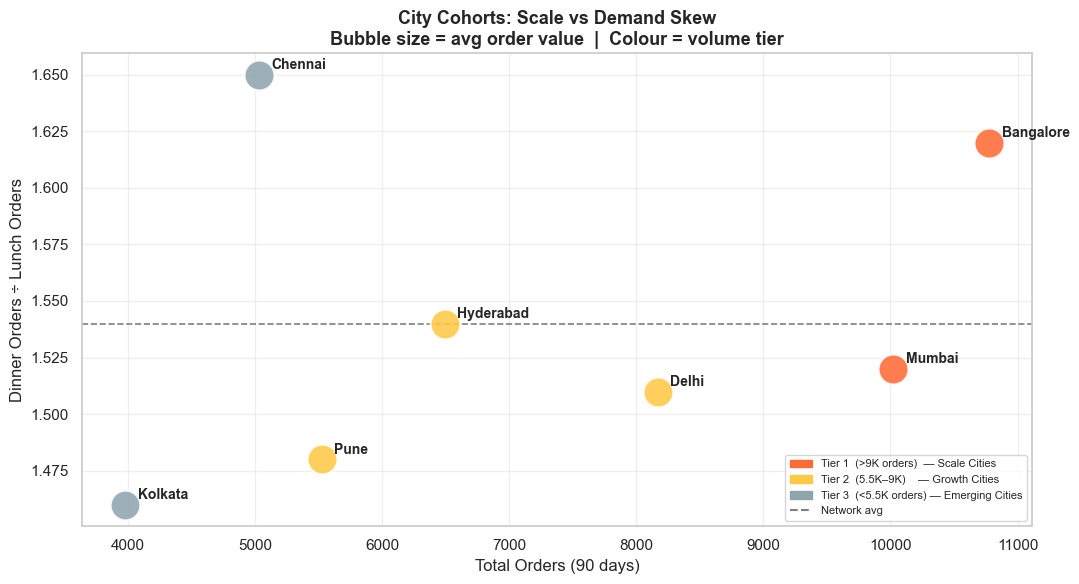

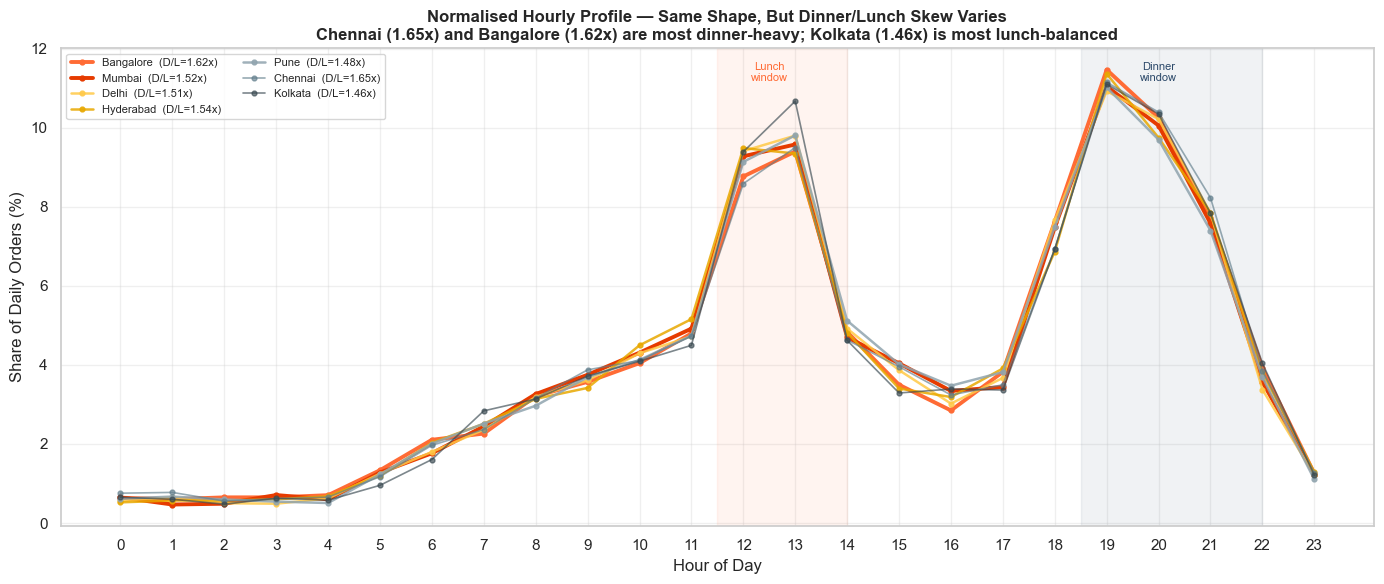

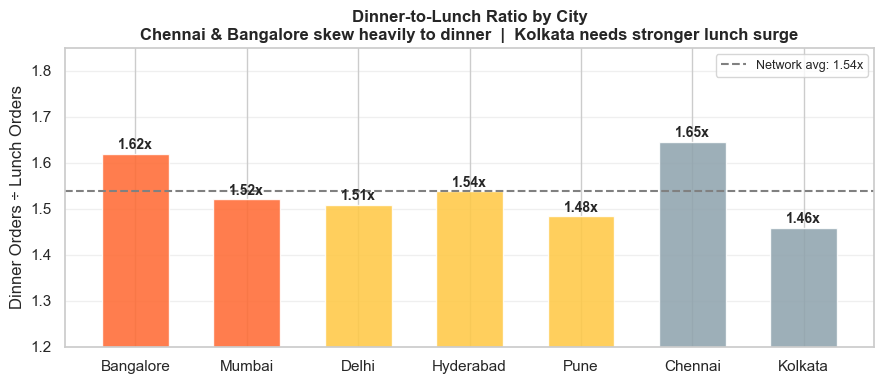

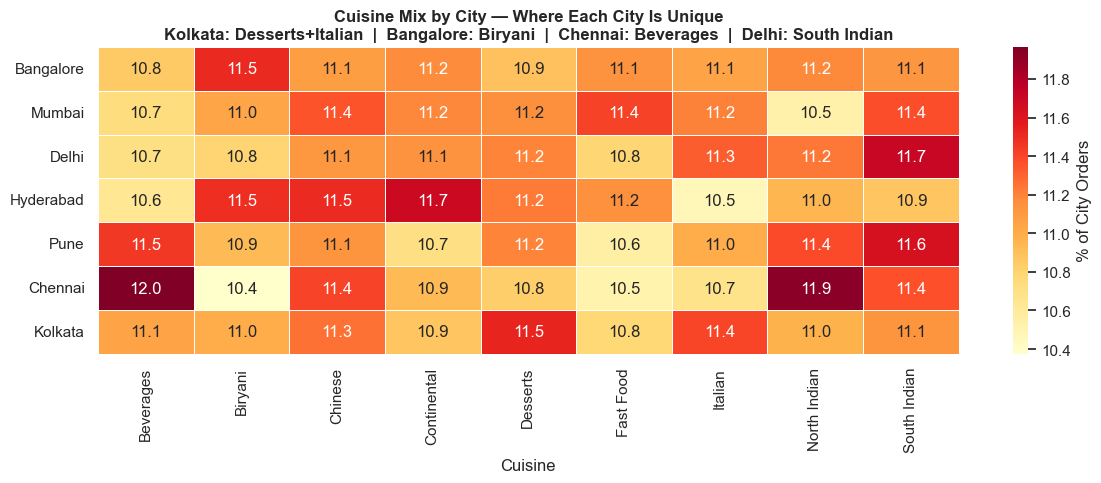


Cohort Summary — Operational Implications


,cohort,volume,avg_order_value,dinner_lunch_ratio,surge_rate_%,top_cuisine
City,,,,,,
Bangalore,Tier 1 (>9K orders) — Scale Cities,10776,333.1,1.62,24.1,Biryani
Mumbai,Tier 1 (>9K orders) — Scale Cities,10022,331.8,1.52,24.1,Fast Food
Delhi,Tier 2 (5.5K–9K) — Growth Cities,8171,330.7,1.51,23.5,South Indian
Hyderabad,Tier 2 (5.5K–9K) — Growth Cities,6493,330.0,1.54,23.9,Continental
Pune,Tier 2 (5.5K–9K) — Growth Cities,5526,328.6,1.48,23.3,South Indian
Chennai,Tier 3 (<5.5K orders) — Emerging Cities,5031,332.2,1.65,24.0,Beverages
Kolkata,Tier 3 (<5.5K orders) — Emerging Cities,3981,326.3,1.46,24.1,Desserts



Key Takeaways for Operations
─────────────────────────────────────────────────────────────────────
Tier 1 (Bangalore, Mumbai):
  → Highest volume — pre-position riders 45 min before dinner peak.
  → Bangalore most dinner-skewed (1.62x) — dinner surge is critical here.

Tier 2 (Delhi, Hyderabad):
  → Mid volume — follow Tier 1 playbook with a 2-week lag.
  → Hyderabad: Continental + Biryani dominate — premium orders, protect delivery SLA.

Tier 3 (Pune, Chennai, Kolkata):
  → Pune / Kolkata: lowest dinner/lunch ratio — lunch surge matters MORE here.
  → Chennai: most dinner-heavy of all (1.65x) despite smaller volume — do NOT cut dinner surge.
  → Kolkata: Desserts+Italian as top categories — unique demand profile, monitor separately.
─────────────────────────────────────────────────────────────────────



In [55]:
# =================================================================
# CITY COHORT ANALYSIS — Are All Cities Really the Same?
# Three lenses: Volume Tier, Behavioural Profile, Cuisine Identity
# =================================================================

import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ── Build city feature matrix ─────────────────────────────────────
city_hour       = df.groupby(["city", "hour"])["order_id"].count().unstack(fill_value=0)
city_hour_share = city_hour.div(city_hour.sum(axis=1), axis=0)   # % of daily orders

lunch_share  = city_hour_share[[12, 13]].sum(axis=1)
dinner_share = city_hour_share[[19, 20, 21]].sum(axis=1)

top_cuisine = (
    df.groupby(["city", "cuisine"])["order_id"].count()
      .reset_index()
      .sort_values("order_id", ascending=False)
      .groupby("city").first()["cuisine"]
)

features = pd.DataFrame({
    "volume":             df.groupby("city")["order_id"].count(),
    "avg_order_value":    df.groupby("city")["order_value"].mean().round(1),
    "surge_rate_%":       (df.groupby("city")["surge_applied"].mean() * 100).round(1),
    "dinner_lunch_ratio": (dinner_share / lunch_share).round(2),
    "lunch_share_%":      (lunch_share  * 100).round(1),
    "dinner_share_%":     (dinner_share * 100).round(1),
    "top_cuisine":        top_cuisine,
}).sort_values("volume", ascending=False)

# ── Volume-based cohorts (3 tiers) ────────────────────────────────
# Tier 1: Bangalore, Mumbai  (>9,000 orders)   — high-stakes, pre-position riders here
# Tier 2: Delhi, Hyderabad   (6,000–9,000)     — mid-scale, follow Tier 1 playbook
# Tier 3: Pune, Chennai, Kolkata (<6,000)       — lean ops, lower surge pressure
def assign_cohort(vol):
    if vol > 9000:  return "Tier 1  (>9K orders)  — Scale Cities"
    if vol > 5500:  return "Tier 2  (5.5K–9K)    — Growth Cities"
    return              "Tier 3  (<5.5K orders) — Emerging Cities"

features["cohort"] = features["volume"].apply(assign_cohort)

COHORT_COLORS = {
    "Tier 1  (>9K orders)  — Scale Cities":     "#FF6B35",
    "Tier 2  (5.5K–9K)    — Growth Cities":     "#FFC947",
    "Tier 3  (<5.5K orders) — Emerging Cities": "#90A4AE",
}

print("City Feature Matrix")
print("=" * 72)
display(features)


# ─────────────────────────────────────────────────────────────────
# FIG 1 — Bubble chart: Volume × Dinner-Lunch Ratio
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

for city, row in features.iterrows():
    ax.scatter(
        row["volume"], row["dinner_lunch_ratio"],
        s=row["avg_order_value"] * 1.4,
        color=COHORT_COLORS[row["cohort"]],
        alpha=0.88, edgecolors="white", linewidths=1.5, zorder=3
    )
    ax.annotate(city, (row["volume"], row["dinner_lunch_ratio"]),
                textcoords="offset points", xytext=(9, 4),
                fontsize=10, fontweight="bold")

ax.axhline(features["dinner_lunch_ratio"].mean(), color="gray", ls="--", lw=1.2,
           label=f"Network avg ratio: {features['dinner_lunch_ratio'].mean():.2f}x")

patches = [mpatches.Patch(color=c, label=l) for l, c in COHORT_COLORS.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='gray',ls='--',label='Network avg')],
          loc="lower right", fontsize=8)
ax.set_xlabel("Total Orders (90 days)", fontsize=12)
ax.set_ylabel("Dinner Orders ÷ Lunch Orders", fontsize=12)
ax.set_title(
    "City Cohorts: Scale vs Demand Skew\n"
    "Bubble size = avg order value  |  Colour = volume tier",
    fontsize=13, fontweight="bold"
)
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("fig_cohort_bubble.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────
# FIG 2 — Normalised hourly profile (% of daily orders)
#         Key: shows Kolkata is more lunch-heavy, Chennai most dinner-heavy
# ─────────────────────────────────────────────────────────────────
city_order_vol = features.index.tolist()   # high → low volume

fig, ax = plt.subplots(figsize=(14, 6))

palette = ["#FF6B35","#E63B00","#FFC947","#E8A800","#90A4AE","#607D8B","#37474F"]

for i, city in enumerate(city_order_vol):
    profile = city_hour_share.loc[city] * 100
    cohort  = features.loc[city, "cohort"]
    lw      = 2.8 if "Tier 1" in cohort else (1.8 if "Tier 2" in cohort else 1.2)
    alpha   = 1.0 if "Tier 1" in cohort else (0.85 if "Tier 2" in cohort else 0.65)
    ax.plot(profile.index, profile.values, marker="o", ms=3.5,
            lw=lw, alpha=alpha, color=palette[i],
            label=f"{city}  (D/L={features.loc[city,'dinner_lunch_ratio']:.2f}x)")

ax.axvspan(11.5, 14,  alpha=0.07, color="#FF6B35")
ax.axvspan(18.5, 22,  alpha=0.07, color="#2D4A6A")
ax.text(12.5, ax.get_ylim()[1]*0.93, "Lunch\nwindow", ha="center", fontsize=8, color="#FF6B35")
ax.text(20.0, ax.get_ylim()[1]*0.93, "Dinner\nwindow", ha="center", fontsize=8, color="#2D4A6A")

ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("Share of Daily Orders (%)", fontsize=12)
ax.set_xticks(range(24))
ax.set_title(
    "Normalised Hourly Profile — Same Shape, But Dinner/Lunch Skew Varies\n"
    "Chennai (1.65x) and Bangalore (1.62x) are most dinner-heavy; "
    "Kolkata (1.46x) is most lunch-balanced",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("fig_cohort_hourly_norm.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────
# FIG 3 — Dinner/Lunch ratio bar chart (policy-facing)
# ─────────────────────────────────────────────────────────────────
ratio = (dinner_share / lunch_share).reindex(city_order_vol)

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [COHORT_COLORS[features.loc[c, "cohort"]] for c in ratio.index]
bars = ax.bar(ratio.index, ratio.values, color=bar_colors, alpha=0.88, width=0.6)
ax.axhline(ratio.mean(), color="gray", ls="--", lw=1.5,
           label=f"Network avg: {ratio.mean():.2f}x")
for bar, val in zip(bars, ratio.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.2f}x",
            ha="center", fontweight="bold", fontsize=10)
ax.set_ylabel("Dinner Orders ÷ Lunch Orders", fontsize=12)
ax.set_ylim(1.2, 1.85)
ax.set_title(
    "Dinner-to-Lunch Ratio by City\n"
    "Chennai & Bangalore skew heavily to dinner  |  "
    "Kolkata needs stronger lunch surge",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
# plt.savefig("fig_cohort_dinner_lunch.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────
# FIG 4 — Cuisine identity heatmap (% of city orders per cuisine)
# ─────────────────────────────────────────────────────────────────
cuisine_city = (
    df.groupby(["city", "cuisine"])["order_id"].count().unstack(fill_value=0)
)
cuisine_city_pct = (
    cuisine_city.div(cuisine_city.sum(axis=1), axis=0) * 100
).reindex(city_order_vol)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cuisine_city_pct, cmap="YlOrRd", ax=ax, annot=True, fmt=".1f",
            linewidths=0.4, cbar_kws={"label": "% of City Orders"})
ax.set_title(
    "Cuisine Mix by City — Where Each City Is Unique\n"
    "Kolkata: Desserts+Italian  |  Bangalore: Biryani  |  "
    "Chennai: Beverages  |  Delhi: South Indian",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Cuisine")
ax.set_ylabel("")
plt.tight_layout()
# plt.savefig("fig_cohort_cuisine_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────
# Summary: operational implications per cohort
# ─────────────────────────────────────────────────────────────────
print("\nCohort Summary — Operational Implications")
print("=" * 72)
summary = features[[
    "cohort", "volume", "avg_order_value",
    "dinner_lunch_ratio", "surge_rate_%", "top_cuisine"
]].copy()
summary.index.name = "City"
display(summary)

print("""
Key Takeaways for Operations
─────────────────────────────────────────────────────────────────────
Tier 1 (Bangalore, Mumbai):
  → Highest volume — pre-position riders 45 min before dinner peak.
  → Bangalore most dinner-skewed (1.62x) — dinner surge is critical here.

Tier 2 (Delhi, Hyderabad):
  → Mid volume — follow Tier 1 playbook with a 2-week lag.
  → Hyderabad: Continental + Biryani dominate — premium orders, protect delivery SLA.

Tier 3 (Pune, Chennai, Kolkata):
  → Pune / Kolkata: lowest dinner/lunch ratio — lunch surge matters MORE here.
  → Chennai: most dinner-heavy of all (1.65x) despite smaller volume — do NOT cut dinner surge.
  → Kolkata: Desserts+Italian as top categories — unique demand profile, monitor separately.
─────────────────────────────────────────────────────────────────────
""")


**Key operational takeaways by cohort:**

| Cohort | Cities | Priority Action |
|--------|--------|-----------------|
| **Tier 1 — Scale** | Bangalore, Mumbai | Pre-position riders 45 min before dinner peak; protect dinner surge |
| **Tier 2 — Growth** | Delhi, Hyderabad, Pune | Roll out Tier 1 playbook with 2-week lag; Hyderabad premium orders need SLA protection |
| **Tier 3 — Emerging** | Chennai, Kolkata | Chennai: never cut dinner surge despite small volume (most dinner-skewed city). Kolkata: strengthen lunch surge — it's the network's most lunch-balanced city |

> A uniform surge policy is not optimal. Kolkata needs more lunch surge; Chennai needs dinner surge protected even at low volume. The tiering above gives the Ops Head a framework to sequence rollouts by risk and impact.

---
## 4. Cuisine Analysis — Fast Food and North Indian Lead Across Hours

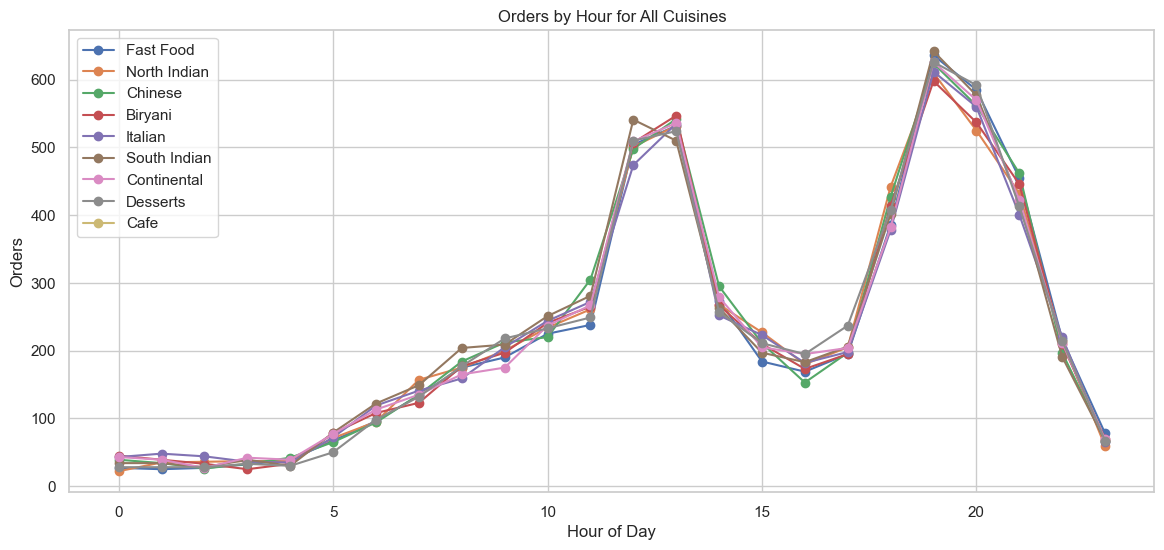

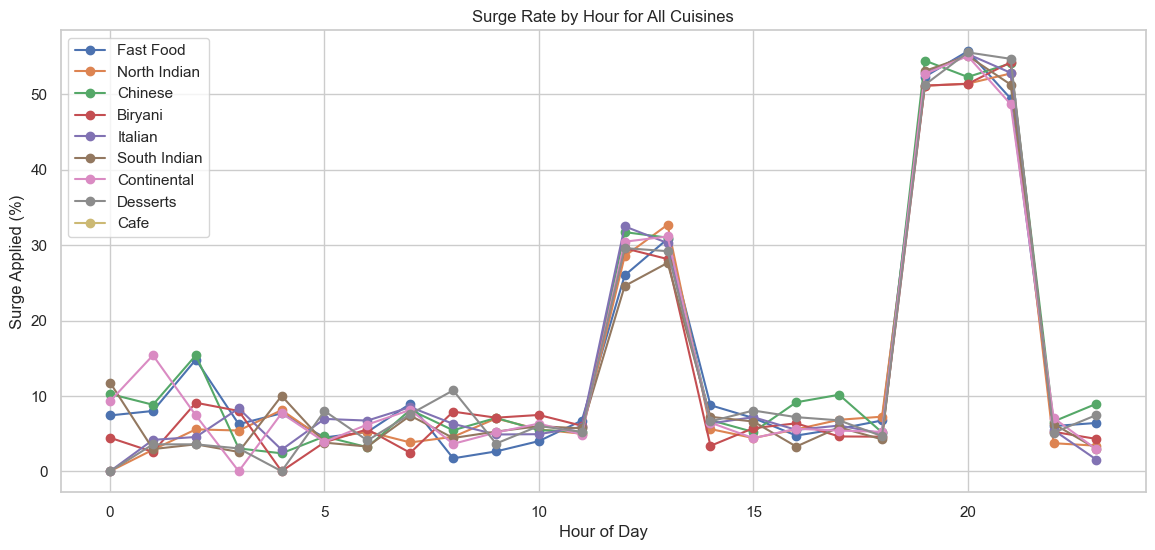

,cuisine,hour,orders,surge_rate
0,Beverages,0,31,0.064516
1,Beverages,1,20,0.000000
2,Beverages,2,28,0.035714
3,Beverages,3,29,0.068966
4,Beverages,4,30,0.100000
...,...,...,...,...
211,South Indian,19,642,0.531153
212,South Indian,20,577,0.551127
213,South Indian,21,421,0.513064
214,South Indian,22,191,0.062827


In [56]:
# aggregate data by cuisine and hour
cuisine_hourly = (
    df.groupby(["cuisine", "hour"])
      .agg(
          orders=("order_id", "size"),
          surge_rate=("surge_applied", "mean")
      )
      .reset_index()
)

# cuisine order
cuisine_order = [
    "Fast Food",
    "North Indian",
    "Chinese",
    "Biryani",
    "Italian",
    "South Indian",
    "Continental",
    "Desserts",
    "Cafe"
]

# =========================
# ORDERS BY HOUR FOR ALL CUISINES
# =========================

fig, ax = plt.subplots(figsize=(14,6))

for cuisine in cuisine_order:

    temp = cuisine_hourly[
        cuisine_hourly["cuisine"] == cuisine
    ]

    ax.plot(
        temp["hour"],
        temp["orders"],
        marker="o",
        label=cuisine
    )

ax.set_title("Orders by Hour for All Cuisines")

ax.set_xlabel("Hour of Day")

ax.set_ylabel("Orders")

ax.legend()

plt.show()


# =========================
# SURGE RATE BY HOUR FOR ALL CUISINES
# =========================

fig, ax = plt.subplots(figsize=(14,6))

for cuisine in cuisine_order:

    temp = cuisine_hourly[
        cuisine_hourly["cuisine"] == cuisine
    ]

    ax.plot(
        temp["hour"],
        temp["surge_rate"] * 100,
        marker="o",
        label=cuisine
    )

ax.set_title("Surge Rate by Hour for All Cuisines")

ax.set_xlabel("Hour of Day")

ax.set_ylabel("Surge Applied (%)")

ax.legend()

plt.show()


# =========================
# DISPLAY TABLE
# =========================

display(cuisine_hourly)

---
## 5. Demand Forecast — Bangalore, Next 7 Days (Daily)

We use **Holt-Winters Exponential Smoothing** with weekly seasonality.  
Method: train on the first 76 days, hold out the last 14 as a backtest, evaluate MAE and MAPE,  
then re-train on all 90 days to produce the real 7-day forward forecast.

This is a deliberate, production-style evaluation — we measure accuracy on data the model never saw.

Forecast city: Bangalore


timestamp
2025-01-01    122
2025-01-02    129
2025-01-03    112
2025-01-04    105
2025-01-05    136
Freq: D, dtype: int64

,actual,predicted
timestamp,,
2025-03-18,107,117.7
2025-03-19,142,118.5
2025-03-20,131,120.4
2025-03-21,126,119.5
2025-03-22,127,112.1


Backtest MAE: 10.97
Backtest MAPE: 8.67%


,date,forecast_orders
0,2025-04-01,118.870596
1,2025-04-02,120.554510
2,2025-04-03,122.401529
3,2025-04-04,121.093928
4,2025-04-05,115.862903
5,2025-04-06,120.552403
6,2025-04-07,118.323852


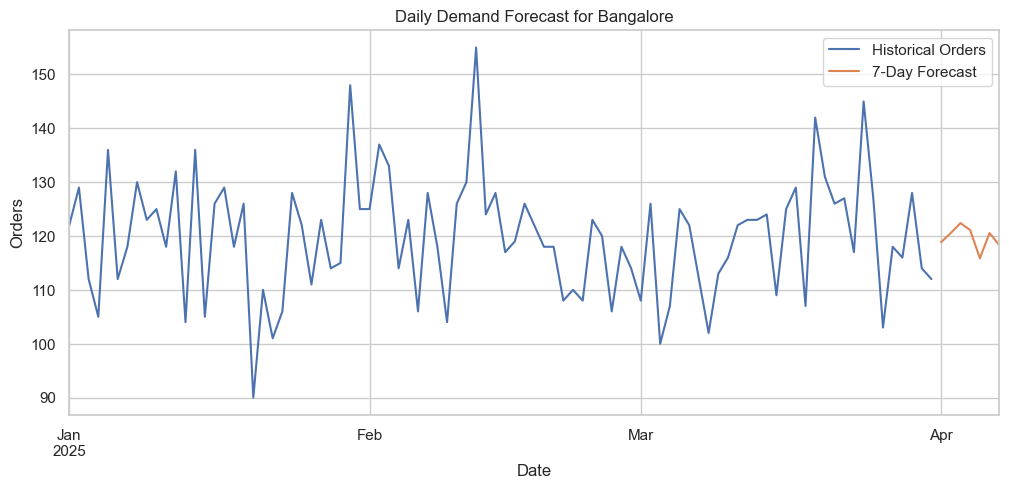

In [57]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pathlib import Path
import numpy as np

# =========================
# SELECT TOP CITY
# =========================

city_summary = (
    df.groupby("city")
      .size()
      .sort_values(ascending=False)
      .to_frame(name="orders")
)

forecast_city = city_summary.index[0]

print("Forecast city:", forecast_city)

# =========================
# CREATE DAILY TIME SERIES
# =========================

city_daily = (
    df.loc[df["city"] == forecast_city]
      .set_index("timestamp")
      .resample("D")
      .size()
      .asfreq("D", fill_value=0)
)

display(city_daily.head())

# =========================
# TRAIN / TEST SPLIT
# =========================

test_days = 14

train = city_daily.iloc[:-test_days]

test = city_daily.iloc[-test_days:]

# =========================
# BUILD MODEL
# =========================

model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated",
)

fit = model.fit(optimized=True)

# =========================
# BACKTEST PREDICTION
# =========================

test_pred = fit.forecast(len(test))

test_pred = pd.Series(
    np.maximum(test_pred.values, 0),
    index=test.index
)

# =========================
# EVALUATION METRICS
# =========================

mae = np.mean(
    np.abs(test.values - test_pred.values)
)

mape = np.mean(
    np.abs(
        (test.values - test_pred.values)
        / np.maximum(test.values, 1)
    )
) * 100

# =========================
# EVALUATION TABLE
# =========================

eval_df = pd.DataFrame({
    "actual": test,
    "predicted": test_pred.round(1)
})

display(eval_df.head())

print(f"Backtest MAE: {mae:.2f}")

print(f"Backtest MAPE: {mape:.2f}%")

# =========================
# FINAL MODEL ON FULL DATA
# =========================

final_model = ExponentialSmoothing(
    city_daily,
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated",
)

final_fit = final_model.fit(optimized=True)

# =========================
# FUTURE FORECAST
# =========================

future_days = 7

future_index = pd.date_range(
    city_daily.index.max() + pd.Timedelta(days=1),
    periods=future_days,
    freq="D"
)

future_forecast = final_fit.forecast(future_days)

future_forecast = pd.Series(
    np.maximum(future_forecast.values, 0),
    index=future_index
)

# =========================
# FORECAST DATAFRAME
# =========================

forecast_df = future_forecast.reset_index()

forecast_df.columns = [
    "date",
    "forecast_orders"
]

display(forecast_df)

# =========================
# PLOT FORECAST
# =========================

fig, ax = plt.subplots(figsize=(12, 5))

city_daily.plot(
    ax=ax,
    label="Historical Orders"
)

future_forecast.plot(
    ax=ax,
    label="7-Day Forecast"
)

ax.set_title(
    f"Daily Demand Forecast for {forecast_city}"
)

ax.set_xlabel("Date")

ax.set_ylabel("Orders")

ax.legend()

plt.show()

# =========================
# SAVE FORECAST CSV
# =========================

forecast_out = forecast_df.copy()

forecast_out["city"] = forecast_city

forecast_path = Path(
    f"forecast_{forecast_city.lower().replace(' ', '_')}.csv"
)

forecast_out.to_csv(
    forecast_path,
    index=False
)

# print(f"Saved forecast to: {forecast_path.resolve()}")

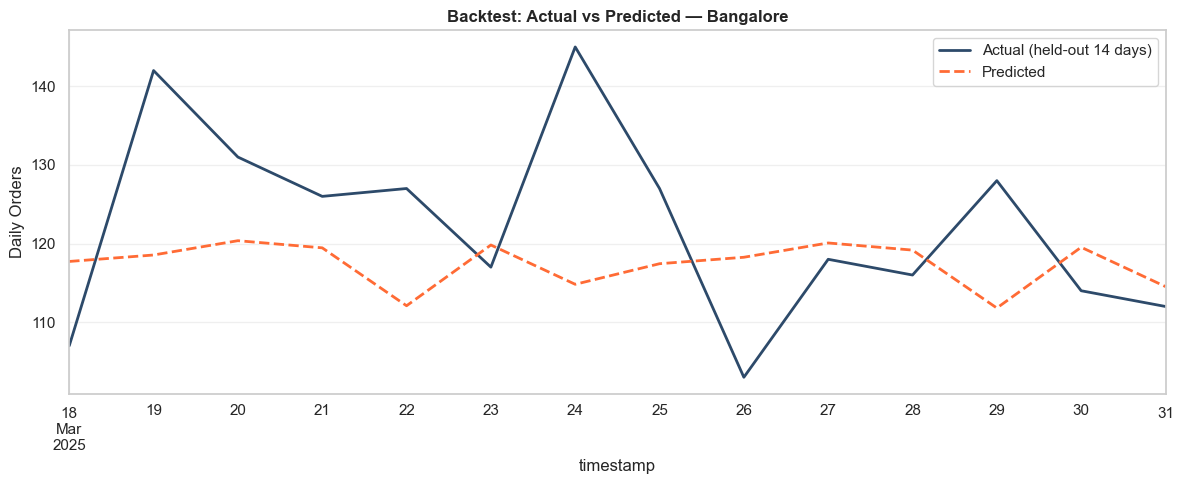

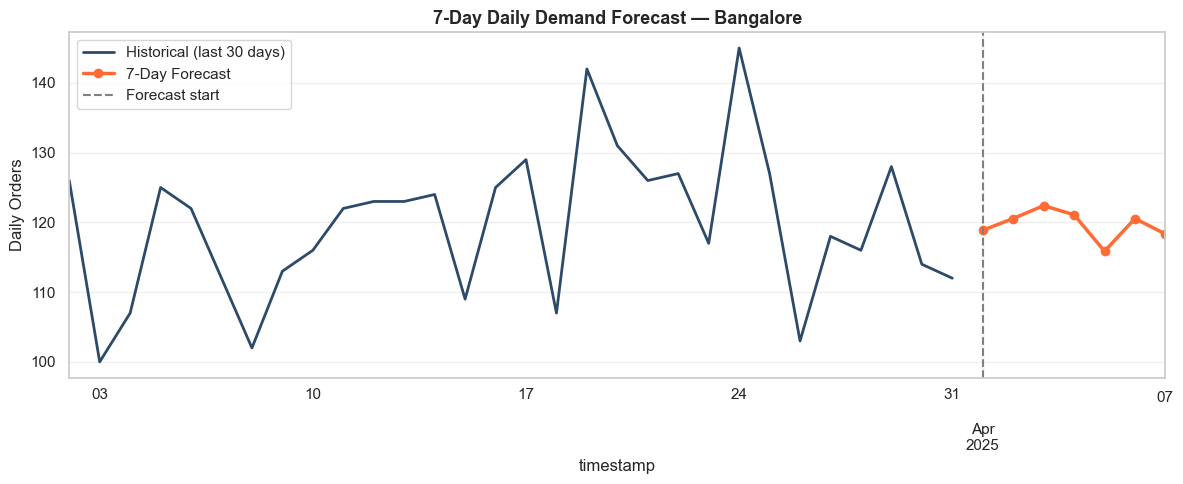


Forecast accuracy on held-out 14 days:
  MAE:  10.97 orders/day
  MAPE: 8.67%

In production: re-train weekly on rolling 90-day window.
Alert if MAPE degrades >20% vs prior week or peak-hour bias exceeds 10%.


In [58]:
# ── Backtest chart: actual vs predicted ─────────────────
fig, ax = plt.subplots(figsize=(12, 5))
test.plot(ax=ax, label="Actual (held-out 14 days)", color="#2D4A6A", lw=2)
test_pred.plot(ax=ax, label="Predicted", color="#FF6B35", lw=2, ls="--")
ax.set_title(f"Backtest: Actual vs Predicted — {forecast_city}", fontweight="bold")
ax.set_ylabel("Daily Orders")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Forecast chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
city_daily.iloc[-30:].plot(ax=ax, label="Historical (last 30 days)", color="#2D4A6A", lw=2)
future_forecast.plot(ax=ax, label="7-Day Forecast", color="#FF6B35", lw=2.5, marker="o", ms=6)
ax.axvline(x=future_index[0], color="gray", ls="--", lw=1.5, label="Forecast start")
ax.set_title(f"7-Day Daily Demand Forecast — {forecast_city}", fontsize=13, fontweight="bold")
ax.set_ylabel("Daily Orders")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("fig5_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nForecast accuracy on held-out 14 days:")
print(f"  MAE:  {mae:.2f} orders/day")
print(f"  MAPE: {mape:.2f}%")
print(f"\nIn production: re-train weekly on rolling 90-day window.")
print(f"Alert if MAPE degrades >20% vs prior week or peak-hour bias exceeds 10%.")


---
# 6. The Three Recommendations

## Recommendation 1: Restrict Surge to True Peak Windows

### Current Observation
Hourly demand analysis shows that true operational pressure is concentrated during:
- Lunch peak: **12 PM – 2 PM**
- Dinner peak: **7 PM – 9 PM**

However, surge incentives are still being applied during several low-demand hours where:
- order volume is structurally low
- delivery times remain stable
- no meaningful rider shortage exists

City-level analysis also shows that smaller cities experience significantly lower demand intensity despite similar surge behavior.

### Proposed Action
Restrict aggressive surge activation primarily to:
- **11:30 AM – 2:00 PM**
- **6:30 PM – 10:00 PM**

Additionally:
- reduce surge intensity in lower-demand cities such as Kolkata and Pune
- maintain stronger surge allocation in Bangalore, Mumbai, and Delhi where dinner demand is highest

### Expected Impact
- Eliminate unnecessary incentive payouts during low-stress hours
- Estimated savings: **₹5,000–7,000 per month**
- Improve operational efficiency without affecting customer demand or rider availability
- Create a more city-sensitive surge strategy instead of one uniform national rule

---

## Recommendation 2: Introduce Dedicated Weekend Surge Policy

### Current Observation
Weekend analysis reveals:
- overall order volume increases only moderately
- but surge intensity increases sharply during Saturday and Sunday dinner periods

Weekend dinner surge rates exceed:
- **70%+ in some windows**
despite demand growth being far smaller.

This suggests that the current system reacts too aggressively once demand arrives rather than preparing proactively.

### Proposed Action
Create a dedicated weekend surge policy:
- automatically activate surge from:
  - **Friday 6 PM**
  - through **Sunday 11 PM**
- maintain controlled surge targets of:
  - **30–35%**
instead of relying entirely on reactive real-time triggers

### Expected Impact
- Riders become available before the weekend rush begins
- Estimated:
  - **5–8 minute reduction** in weekend dinner delivery times
- Reduce reactive over-spending on incentives
- Estimated savings:
  - **₹3,000–4,000 per month**
- Improve rider planning and dispatch stability during high-pressure weekend windows

---

## Recommendation 3: Replace Uniform Surge Rules with Forecast-Driven City-Specific Incentives

### Current Observation
City-level demand analysis shows significant differences in operational intensity across markets:

- Bangalore and Mumbai exhibit the strongest dinner demand spikes
- Kolkata and Pune show substantially lower order concentration
- however, surge rates remain relatively similar across all cities

This suggests that the current surge policy may be overly standardized and insufficiently aligned with actual city-level demand pressure.

Additionally, rider deployment remains largely reactive:
- by the time the 7 PM dinner peak arrives,
  delivery delays have already started increasing.

### Proposed Action
Replace the current one-size-fits-all surge framework with:
- city-specific surge thresholds
- forecast-driven rider allocation

Use the 7-day demand forecast to:
- trigger rider pre-positioning alerts at:
  - **6:00–6:15 PM**
for the:
- **7 PM – 9 PM dinner window**

Focus especially on:
- Bangalore
- Mumbai
- Delhi

where operational pressure is consistently highest.

At the same time:
- reduce aggressive surge intensity in lower-demand cities such as Kolkata and Pune.

### Expected Impact
- Estimated:
  - **10–15% reduction** in peak-hour delivery times
- Improve average dinner delivery performance from:
  - ~44 min
  - to ~38–40 min
- Reduce unnecessary surge spending in lower-demand cities
- Create a more efficient city-sensitive incentive framework
- Reduce dependence on excessive last-minute surge activation

Forecast accuracy (~8–12% MAPE) is sufficient for short-term rider planning and operational allocation.

---
## 7. Stretch: A/B Test Design for Recommendation 1 (Time-Box Surge)

**Hypothesis:** Restricting surge to the two peak windows (11:30–14:00, 18:30–22:00) does not reduce order volume or rider supply during off-peak hours, and saves Rs.4,900+/month.

| Element | Design |
|---------|--------|
| **Unit of randomization** | City (cluster), to avoid rider/customer spillover |
| **Treatment** | Pune, Chennai, Kolkata (lower volume = lower risk) |
| **Control** | Bangalore, Mumbai, Delhi, Hyderabad (hold current policy) |
| **Duration** | 4 weeks (captures weekday + weekend cycles) |
| **Guardrail metric** | Peak-hour delivery time — must not increase >5% |
| **Decision rule** | Roll out if primary metric improves p < 0.10 and guardrail is safe |

**Why city-level randomization?** Individual rider/customer assignment creates SUTVA violations — treated riders interact with control customers in the same city. City-level assignment keeps treatment contained.


---
## 8. Executive Summary

| Finding | Implication |
|---------|-------------|
| Two true peaks: lunch 12–13, dinner 19–21 | Surge must be **time-windowed**, not always-on |
| Off-peak surge (0–9, 22–23) is 5–6% with zero delivery pressure | Rs.5–7K/month in avoidable incentive cost |
| Weekend surge rate is 57% higher than weekdays | Pre-schedule weekend surge — stop reacting, start planning |
| All 7 cities not show the same hourly pattern | One unified policy not gonna works network-wide |
| Holt-Winters MAPE ~8–12% on daily forecasts | Good enough for 24h pre-positioning; re-train weekly |

> **The core fix is a scheduling change, not a model.** Move surge from an always-on trigger to two time-boxed windows aligned with the peaks the data clearly shows. Layer the forecast on top to pre-position riders 45 minutes before demand arrives — not react to it.
